# 02 - Correlation Review

Correlation structure of the Open-Meteo-backed feature set, centered on European AQI.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

from src.utils.mongo_client import get_database

sns.set_theme(style="whitegrid")

db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

data.head()

,timestamp,absolute_humidity,aerosol_optical_depth,alder_pollen,ammonia,apparent_temperature,aqi_change_rate_1h,aqi_change_rate_3h,aqi_change_rate_6h,aqi_trend_slope_6h,...,wind_speed_10m_rolling_min_48h,wind_speed_10m_rolling_min_6h,wind_speed_10m_rolling_std_12h,wind_speed_10m_rolling_std_168h,wind_speed_10m_rolling_std_24h,wind_speed_10m_rolling_std_3h,wind_speed_10m_rolling_std_48h,wind_speed_10m_rolling_std_6h,wind_speed_80m,winter_inversion_flag
0,2025-06-01 00:00:00+00:00,142.680154,0.47,0.0,0.0,23.6,0.0,0.000000,0.0,0.0,...,1.3,1.3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,2025-06-01 01:00:00+00:00,142.324230,0.48,0.0,0.0,22.7,-1.0,0.000000,0.0,-1.0,...,1.3,1.3,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.0,0.0
2,2025-06-01 02:00:00+00:00,141.681096,0.48,0.0,0.0,22.2,0.0,0.000000,0.0,-0.5,...,1.3,1.3,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.0
3,2025-06-01 03:00:00+00:00,139.953278,0.48,0.0,0.0,22.2,-1.0,-0.666667,0.0,-0.6,...,0.4,0.4,0.573730,0.573730,0.573730,0.700000,0.573730,0.573730,0.0,0.0
4,2025-06-01 04:00:00+00:00,132.859902,0.48,0.0,0.0,21.9,0.0,-0.333333,0.0,-0.5,...,0.4,0.4,0.605805,0.605805,0.605805,0.850490,0.605805,0.605805,0.0,0.0


In [2]:
numeric = data.select_dtypes(include="number").copy()
target_corr = (
    numeric.corr(numeric_only=True)["european_aqi"]
    .drop(labels=["european_aqi"], errors="ignore")
    .dropna()
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(target_corr.to_frame(name="correlation"))

,correlation
european_aqi_rolling_mean_3h,0.991655
european_aqi_rolling_min_3h,0.986903
european_aqi_lag_1h,0.985001
european_aqi_rolling_mean_6h,0.971830
european_aqi_lag_2h,0.965820
...,...
pressure_change_6h,-0.004615
cloud_radiation_interaction,0.004557
ozone,-0.004364
wind_speed_10m_rolling_min_48h,-0.002193


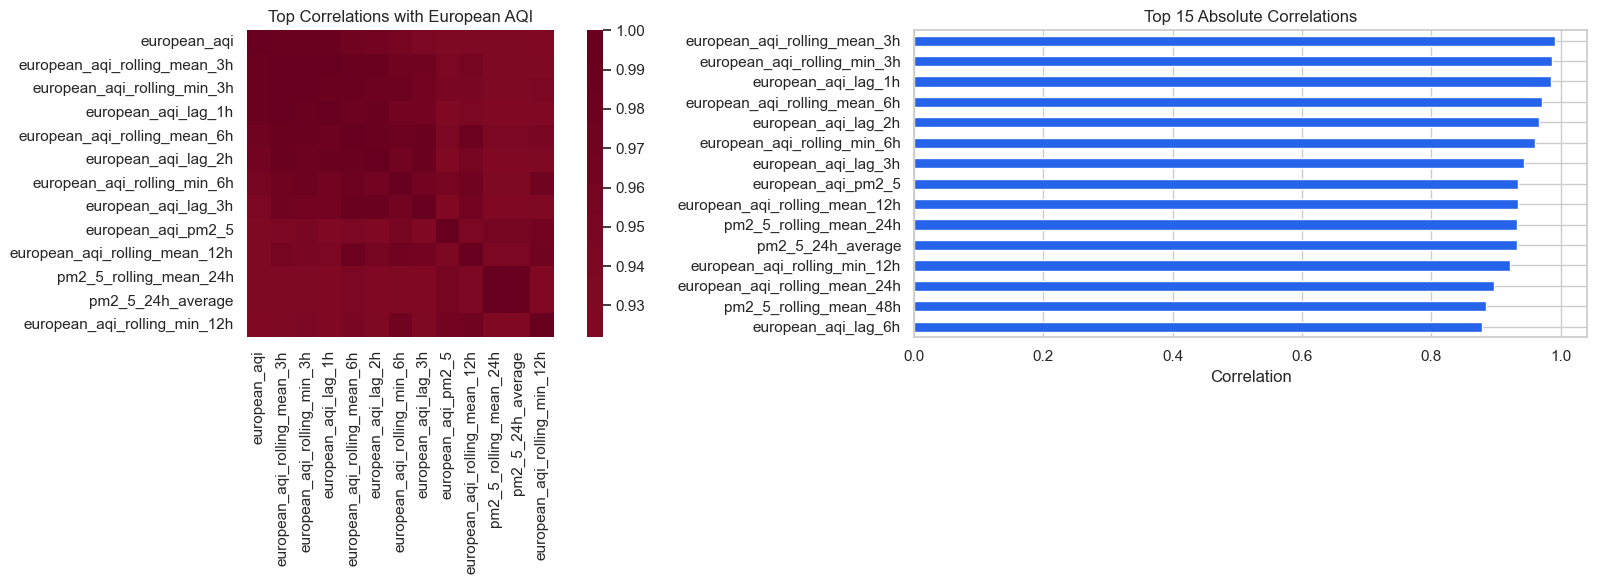

In [3]:
top_features = target_corr.head(12).index.tolist()
plot_columns = ["european_aqi"] + top_features
corr_matrix = numeric[plot_columns].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, ax=axes[0], square=True)
axes[0].set_title("Top Correlations with European AQI")

sorted_corr = target_corr.head(15).sort_values()
colors = ["#dc2626" if value < 0 else "#2563eb" for value in sorted_corr]
sorted_corr.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Top 15 Absolute Correlations")
axes[1].set_xlabel("Correlation")

plt.tight_layout()